### Лекарственный препарат для лечения зависимостей </br>
Целевая характеристика: **Тип лекарственного препарата**</br>
Наборы характеристик:
- Возраст
- Пол
- Уровень артериального давления (АД)
- Уровень холестерина
- Соотношение натрия и калия

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.spatial.distance import cosine
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn import preprocessing
from sklearn import set_config
set_config(transform_output="pandas")

import pandas as pd
import time
url="https://raw.githubusercontent.com/alexsadny/ml-course-homeworks/main/hw03_knn/drug200.csv"
df=pd.read_csv(url)
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


Посмотрим базовую информацию о столбцах

In [20]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB


In [22]:
df.shape

(200, 6)

Посмотрим есть ли пропуски

In [23]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

Посмотрим на баланс классов того, что будем предсказывать

In [24]:
df["Drug"].value_counts(normalize=True)

Drug
DrugY    0.455
drugX    0.270
drugA    0.115
drugC    0.080
drugB    0.080
Name: proportion, dtype: float64

Несбалансированное распределение, скорее всего результаты будут сильно отклоняться, так как классы C и B слишком малы по сравнению с Y

# Подготовка данных
## Разбиение на train/test/validation

In [25]:
X,y=df.drop("Drug",axis=1),df['Drug']

In [26]:
X_t,X_test,y_t,y_test=train_test_split(X, y, stratify=y, test_size=0.15, random_state=42)
X_train,X_val,y_train,y_val=train_test_split(X_t,y_t,stratify=y_t, test_size=0.1764,random_state=42)

### Подготовка данных</br>
Всего три категориальных данных: пол, холестерин, артериальное давление. Надо подумать как закодировать. 

In [27]:
df["Sex"].unique()

<StringArray>
['F', 'M']
Length: 2, dtype: str

In [28]:
df["BP"].unique()

<StringArray>
['HIGH', 'LOW', 'NORMAL']
Length: 3, dtype: str

In [29]:
df["Cholesterol"].unique()

<StringArray>
['HIGH', 'NORMAL']
Length: 2, dtype: str

In [30]:
pd.get_dummies?

Signature:
pd.get_dummies(
    data,
    prefix=None,
    prefix_sep: 'str | Iterable[str] | dict[str, str]' = '_',
    dummy_na: 'bool' = False,
    columns=None,
    sparse: 'bool' = False,
    drop_first: 'bool' = False,
    dtype: 'NpDtype | None' = None,
) -> 'DataFrame'
Docstring:
Convert categorical variable into dummy/indicator variables.

Each variable is converted in as many 0/1 variables as there are different
values. Columns in the output are each named after a value; if the input is
a DataFrame, the name of the original variable is prepended to the value.

Parameters
----------
data : array-like, Series, or DataFrame
    Data of which to get dummy indicators.
prefix : str, list of str, or dict of str, default None
    A string to be prepended to DataFrame column names.
    Pass a list with length equal to the number of columns
    when calling get_dummies on a DataFrame. Alternatively, `prefix`
    can be a dictionary mapping column names to prefixes.
prefix_sep : str, lis

Так как особого опыта в кодировке нет, и у всех есть свои недостатки, то пойдем по пути наименьшего сопротивления и применим One-Hot Encoding

In [31]:
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_cols = ['Cholesterol', 'Sex', 'BP']
enc.fit(X_train[cat_cols])
X_train_encoded = enc.transform(X_train[cat_cols])
X_val_encoded = enc.transform(X_val[cat_cols])
X_test_encoded = enc.transform(X_test[cat_cols])
X_train_encoded

,Cholesterol_HIGH,Cholesterol_NORMAL,Sex_F,Sex_M,BP_HIGH,BP_LOW,BP_NORMAL
165,1.0,0.0,0.0,1.0,0.0,1.0,0.0
9,0.0,1.0,0.0,1.0,0.0,1.0,0.0
108,0.0,1.0,0.0,1.0,1.0,0.0,0.0
70,1.0,0.0,0.0,1.0,1.0,0.0,0.0
73,0.0,1.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...
37,0.0,1.0,0.0,1.0,0.0,1.0,0.0
171,0.0,1.0,0.0,1.0,0.0,1.0,0.0
18,1.0,0.0,0.0,1.0,0.0,1.0,0.0
170,1.0,0.0,1.0,0.0,0.0,0.0,1.0


## Масштабирование данных 

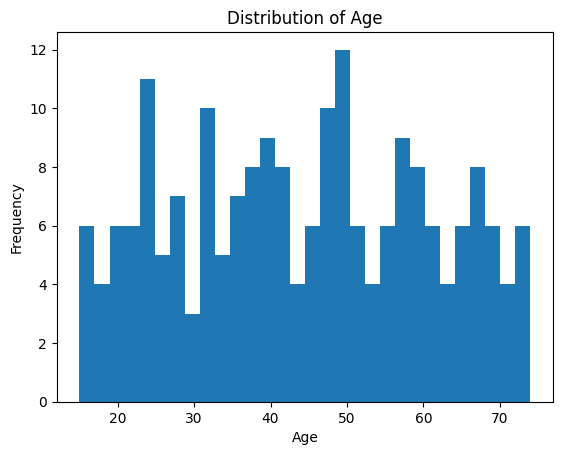

In [32]:
plt.hist(df["Age"], bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

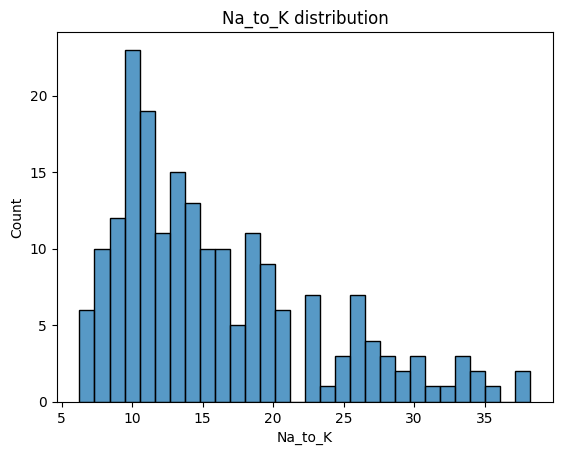

In [33]:
sns.histplot(df["Na_to_K"], bins=30)
plt.title("Na_to_K distribution")
plt.show()

Зависимость соотношения натрия и хлором стремится к нормальному распределению поэтому его будем масштабировать по формуле нормального распределения. Зависимость возраста не похоже на нормальное распределение поэтому его будем масштабировать с помощью стандартизация данных

In [34]:
ct = ColumnTransformer(transformers=[
    ('cat_features', MinMaxScaler(), ['Age']),
    ('num_features', StandardScaler(), ['Na_to_K'])
], 
remainder='passthrough' 
)
X_train_transformed = ct.fit_transform(X_train_encoded)
X_test_transformed = ct.transform(X_test_encoded)
X_val_transformed=ct.transform(X_val_encoded)

ValueError: A given column is not a column of the dataframe

# Почему масштабирование важно для KNN

 масштабирование важно для knn так как или иначе будет различный разброс параметров по расстоянию и какие-то признаки не будут учитываться либо будут учитываться неверно так как большее расстояние от признаков до цели

# Почему нельзя подбирать параметры на тестовой выборке

Подбирая параметр на тестовой выборки можно прийти к переобучению модели, возможной утечки данных и к ложным результатам на других тестах. Дпугими словами мы просто подгоняем хорошие значения для конткректного теста

# Обучим модель 

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_transformed , y_train)
predictions = knn.predict(X_test_transformed )